# Photoelectric Effect
my part is just exercise 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1

For Vstop, *MIGHT HAVE TO REDO TO MAKE USE OF PC*
- make note of the infrared readings being unsteady but consistent, resulting in a range of values and and uncertainty derived from there rather than stddev
- mention blue having 6 readings because we accidentally took data from blue twice

For frequency
- Speed of light from [The NIST Reference on Constants, Units, and Uncertainty](https://physics.nist.gov/cgi-bin/cuu/Value?c|search_for=light)
- Lambda uncertainties taken from spec sheets. Ex. for green: [this sheet](https://thin01mstroc282prod.dxcloud.episerver.net/globalassets/items/m/m5/m53/m530l4/mtn010931-s01.pdf?v=0116010840?v=2026-01-16-13-08-40), from [this page](https://www.thorlabs.com/item/M530L4)

For fitting
- electron charge from [The NIST Reference on Constants, Units, and Uncertainty](https://physics.nist.gov/cgi-bin/cuu/Value?e|search_for=electron+charge)

In [3]:
# Vstop and uncs

# leds = [infrared, red, orange, amber, green, cyan, blue, violet]
Vstop = [0] * 8
Vstop_unc = [0] * 8

# infrared is the only one that was consistent enough to get an immediate
#range of uncertainty
Vstop[0] = 0.0139E-3
Vstop_unc[0] = 2E-3

# get means and stds of other leds
temp = [[0.248203, 0.255650, 0.253633], \
        [0.350805, 0.349953, 0.350917], \
        [0.475091, 0.474304, 0.477611], \
        [0.709742, 0.709770, 0.708871], \
        [0.762652, 0.763626, 0.763610], \
        [1.019481, 1.018401, 1.020074, 1.013627, 1.013577, 1.013826], \
        [1.36214, 1.36210, 1.36118]]
print(len(temp))
for i in range(0, len(temp)):
    t = np.array(temp[i])
    Vstop[i+1] = np.mean(t)
    Vstop_unc[i+1] = np.std(t)

print(Vstop)
print(Vstop_unc)

7
[1.39e-05, 0.25249533333333335, 0.3505583333333333, 0.4756686666666667, 0.7094610000000001, 0.763296, 1.0164976666666667, 1.3618066666666666]
[0.002, 0.0031448546689614837, 0.0004304705435786223, 0.001410516768973545, 0.00041734957369890145, 0.00045542361232886946, 0.0028642026037896773, 0.00044342104395505986]


In [4]:
# frequencies and uncs

# speed of light (no unc)
c = 299792458
# wavelengths
lamb = [940E-9, 660E-9, 617E-9, 590E-9, 530E-9, 508E-9, 455E-9, 395E-9]
lamb_unc = [37E-9, 20E-9, 16E-9, 15E-9, 35E-9, 29E-9, 18E-9, 16E-9]

freq = [0] * 8
freq_unc = [0] * 8
for i in range(0, len(freq)):
    freq[i] = c/lamb[i]
    freq_unc[i] = freq[i]*lamb_unc[i]/lamb[i]

print(freq)
print(freq_unc)

[318928146808510.6, 454230996969696.94, 485887290113452.2, 508122810169491.56, 565646147169811.2, 590142633858267.6, 658884523076923.1, 758968248101265.9]
[12553554714803.078, 13764575665748.393, 12599994557237.012, 12918376529732.836, 37353990850836.59, 33689244846239.684, 26065761352493.66, 30743017644608.24]


7 4.7736584596636785e+29


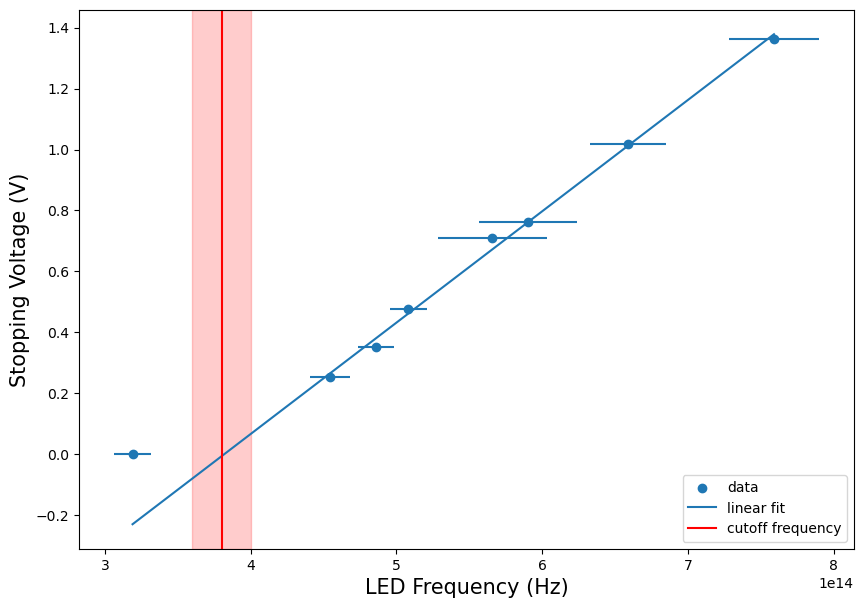

In [22]:
# plot and hope I won't have to redo

# make the data
x = np.array(freq) # frequency
y = np.array(Vstop) # stopping voltage
    
# errorbars
x_err = np.array(freq_unc)
y_err = np.array(Vstop_unc)
    
# plot
fig, ax = plt.subplots()
    
ax.scatter(x, y, label="data")
ax.set_ylabel("Stopping Voltage (V)", fontsize=15)
ax.set_xlabel("LED Frequency (Hz)", fontsize=15)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none')

# fit the line
#p = np.polyfit(x, y, 1)
#m = p[0]
#b = p[1]
#ax.plot(x, m*x+b, label="fit")
#ax.plot(x, 6.63E-34/1.602176634E-19*x+b-0.5, label="correct")

# removing infrared
p = np.polyfit(x[1:], y[1:], 1)
# using polyfit is the same as if calculated 
#   from the uncertainties in linear fit resource
ax.plot(x, p[0]*x+p[1], label="linear fit")
m = p[0]
b = p[1]

# parameter uncertainties
N = len(freq)-1
delta = N*np.sum(x[1:]**2) - np.sum(x[1:])**2
print(N, delta)
covar = np.sum((y[1:]-(b+m*x[1:]))**2)/(N-2)
m_unc = np.sqrt(N*covar/delta)
b_unc = np.sqrt(covar*np.sum(x[1:]**2)/delta)

# stopping frequency from fit
#ax.axvline(x=352729072528896.4, color="red", label="f0 from fit")
#ax.axvline(x=276640437191502.53, color="purple", label="f0 from correct")
ax.axvline(x=3.8E14, color="red", label="cutoff frequency")
ax.axvspan(3.8E14-0.2E14, 3.8E14+0.2E14, color='red', alpha=0.2)

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./Vstopf.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [54]:
print(m, "±", m_unc)
print(b, "±", b_unc)

e = 1.602176634E-19 # no unc

print()
h = np.array(m) * e
h_unc = h*m_unc/m
print("h:", h, "±", h_unc)

f0 = b*e/h * -1
f0_unc = f0*np.sqrt((b_unc/b)**2 + (h_unc/h)**2)
print("f0:", f0, "±", f0_unc)
print("f0:", 3.8E14, "±", 0.2E14)


E0 = f0 * h
E0_unc = E0 * np.sqrt((f0_unc/f0)**2 + (h_unc/h)**2)
print("E0 (J):", E0, "±", E0_unc)
# to eV
E0_eV = E0/1.602176634E-19
E0_eV_unc = E0_eV * E0_unc/E0
print("E0 (eV):", E0_eV, "±", E0_eV_unc)

print()
E0_alt = -b*e
E0_alt_unc = E0_alt * b_unc/b
print(E0_alt, "±", E0_alt_unc)


#ftest = b*1.602176634E-19/6.63E-34 * -1
#print("ftest:", ftest)
#print()
#h2 = np.array(p[0]) * 1.602176634E-19 # * e
#print(h2)

3.656726996179639e-15 ± 9.287243662295843e-17
-1.3967347418680305 ± 0.05414194007382646

h: 5.858722550196025e-34 ± 1.4879804789994985e-35
f0: 381963089759576.6 ± 17701137044006.824
f0: 380000000000000.0 ± 20000000000000.0
E0 (J): 2.23781576731698e-19 ± 1.182590518862336e-20
E0 (eV): 1.3967347418680307 ± 0.07381149454850533

2.23781576731698e-19 ± -8.674495130571299e-21


### Residuals

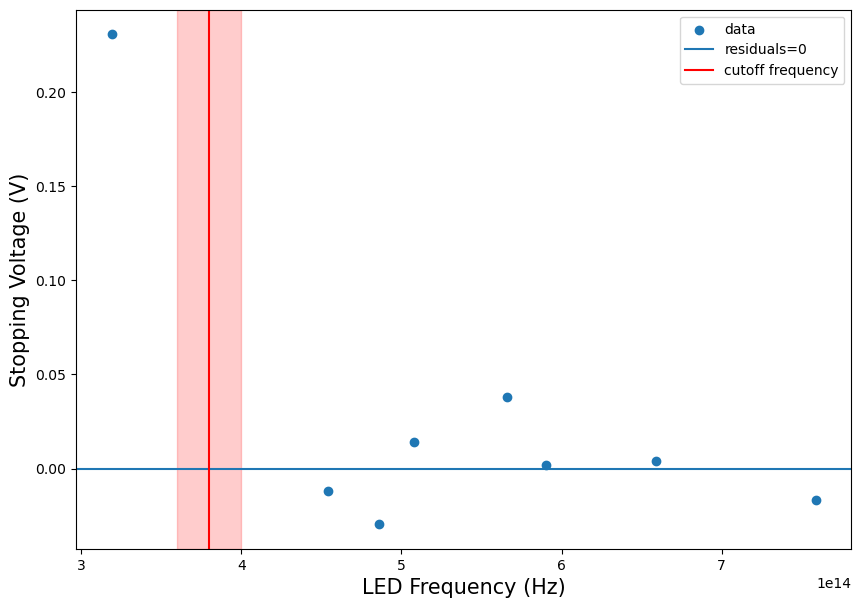

In [30]:
fig, ax = plt.subplots()

# make the data
x = np.array(freq) # frequency
y = np.array(Vstop) # stopping voltage
    
# errorbars
x_err = np.array(freq_unc)
y_err = np.array(Vstop_unc)

# line of best fit
# - outliers already corrected for 0 and 8
fit = m*x+b

res = y-fit
    
# plot
ax.scatter(x, res, label="data")
ax.set_ylabel("Stopping Voltage (V)", fontsize=15)
ax.set_xlabel("LED Frequency (Hz)", fontsize=15)
#ax.errorbar(x, res, xerr=x_err, yerr=y_err, fmt='none')
ax.axhline(y=0, label="residuals=0")
    
# stopping frequency from fit
#ax.axvline(x=352729072528896.4, color="red", label="f0 from fit")
#ax.axvline(x=276640437191502.53, color="purple", label="f0 from correct")
ax.axvline(x=3.8E14, color="red", label="cutoff frequency")
ax.axvspan(3.8E14-0.2E14, 3.8E14+0.2E14, color='red', alpha=0.2)

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./Vstopf_res.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

### linear correlation coefficient

In [48]:
r = np.corrcoef(x, y)
print(r)

[[1.         0.98947902]
 [0.98947902 1.        ]]


### Chi-squared test for goodness of fit

In [41]:
# w/o infrared
y_avg = np.mean(y[1:]) 
chisq = 0
print(y)
print(y_avg)
print(fit)
print()

for i in range(1, len(freq)):
    num = (y[i]-fit[i])**2
    denom = (y[i]-y_avg)**2
    chisq += num/denom
print(chisq)
chisq = np.sum((y[1:]-fit[1:])**2/(y[1:]-y_avg)**2)
print(chisq)
print(N)
redchisq = chisq/(N-2)
print(redchisq)

[1.39000000e-05 2.52495333e-01 3.50558333e-01 4.75668667e-01
 7.09461000e-01 7.63296000e-01 1.01649767e+00 1.36180667e+00]
0.7042548095238095
[-0.23050158  0.26426401  0.38002243  0.46133166  0.67167879  0.76125576
  1.01262608  1.37860494]

52.68005739062651
52.68005739062651
7
10.536011478125301


TODO
- chi-squared goodness of fit test

## Exercise 2
plot photocurrent against intensity, and stopping voltage against intensity

### Add data

In [61]:
# intensity
intensity = [1, 2, 3, 4, 5]

# stopping voltage
SV = [[0.704733, 0.704776, 0.705588], \
      [0.712122, 0.712497, 0.711261], \
      [0.715270, 0.716046, 0.713617], \
      [0.718040, 0.716966, 0.716794], \
      [0.717577, 0.718105, 0.718331]]
y_SV = [0] * len(intensity)
y_SV_unc = [0] * len(y_VS)
for i in range(0, len(intensity)):
    y_SV[i] = np.mean(np.array(SV[i]))
    y_SV_unc[i] = np.std(np.array(SV[i]))

# photocurrent

# remember to convert units!
bounds = [[33.24, 33.31], \
          [58.207, 58.231], \
          [75.571, 75.586], \
          [84.986, 85.003], \
          [95.395, 95.571]]
y_PC = [0] * len(intensity)
y_PC_unc = [0] * len(y_PC)
for i in range(0, len(intensity)):
    y_PC[i] = np.mean(np.array(bounds[i]))*10**(-8)
    y_PC_unc[i] = np.std(np.array(bounds[i]))*10**(-8)

print(y_VS)
print(y_VS_unc)
print()
print(y_PC)
print(y_PC_unc)

[0.7050323333333334, 0.71196, 0.7149776666666666, 0.7172666666666667, 0.7180043333333334]
[0.0003933076262785693, 0.0005174340537691788, 0.0010129509146822313, 0.0005513192259380069, 0.0003159423294773285]

[3.3275000000000006e-07, 5.821900000000001e-07, 7.557849999999999e-07, 8.499450000000001e-07, 9.548300000000001e-07]
[3.5000000000000143e-10, 1.2000000000000455e-10, 7.500000000000284e-11, 8.499999999997954e-11, 8.800000000000097e-10]


### plot PC vs Intensity
The linear fits don't look too good but it's definitely not the worst I've seen, so we'll take it.

5 50
m: 1.5119149999999998e-07 ± 1.877659005916674e-08
b: 2.4152550000000016e-07 ± 6.227490406857317e-08


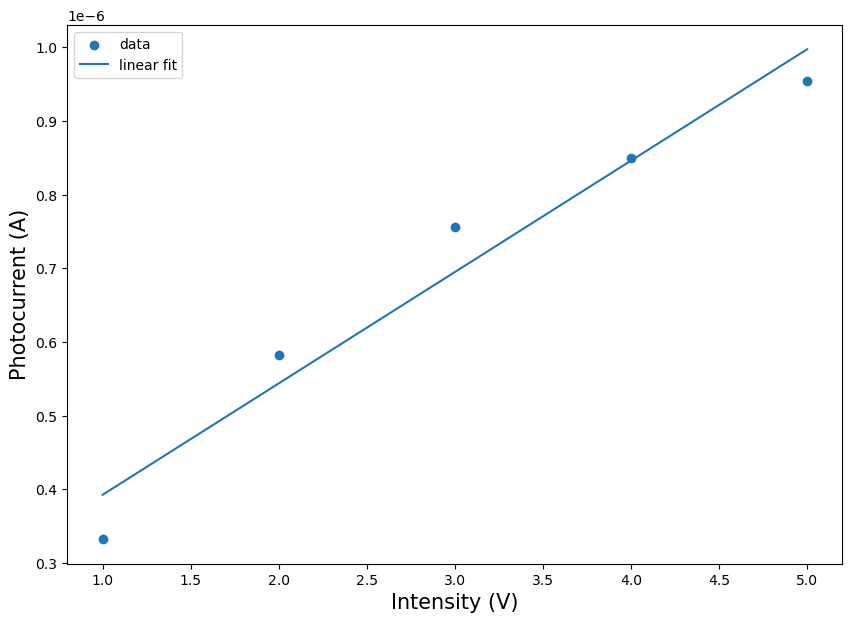

In [79]:
# PC VS INTENSITY
fig, ax = plt.subplots()

# make the data
x = np.array(intensity) # intensity
y = np.array(y_PC) # photocurrent
    
# errorbars
y_err = np.array(y_PC_unc)

# plot
ax.scatter(x, y, label="data")
ax.set_ylabel("Photocurrent (A)", fontsize=15)
ax.set_xlabel("Intensity (V)", fontsize=15)
ax.errorbar(x, y, yerr=y_err, fmt='none')

# fit the line
p = np.polyfit(x, y, 1)
m = p[0]
b = p[1]
ax.plot(x, m*x+b, label="linear fit")
#ax.plot(x, 6.63E-34/1.602176634E-19*x+b-0.5, label="correct")

# parameter uncertainties
N = len(intensity)
delta = N*np.sum(x**2) - np.sum(x)**2
print(N, delta)
covar = np.sum((y-(b+m*x))**2)/(N-2)
m_unc = np.sqrt(N*covar/delta)
b_unc = np.sqrt(covar*np.sum(x**2)/delta)

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./PCint.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

print("m:", m, "±", m_unc)
print("b:", b, "±", b_unc)

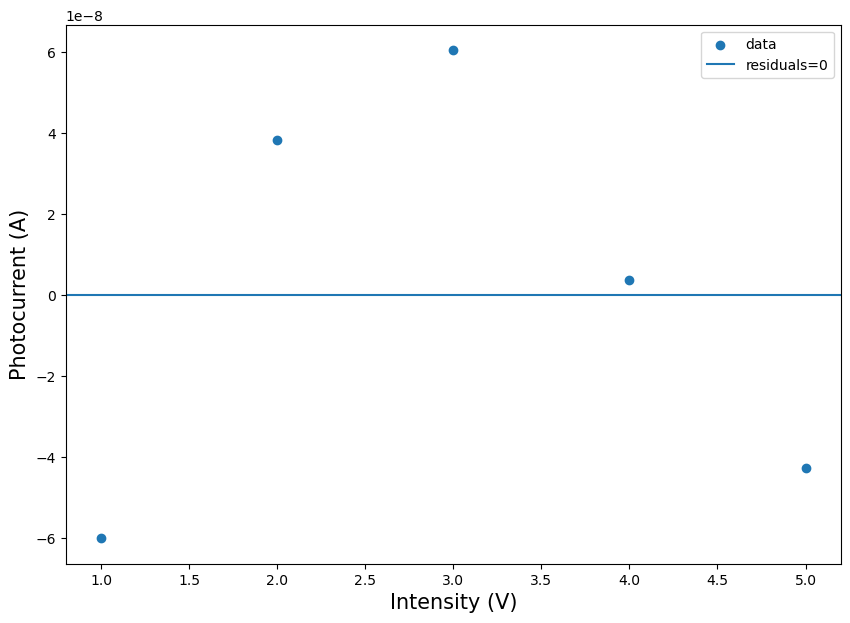

In [80]:
# residuals
fig, ax = plt.subplots()

# make the data
x = np.array(intensity) # intensity
y = np.array(y_PC) # photocurrent
    
# errorbars
y_err = np.array(y_PC_unc)

# line of best fit
# - outliers already corrected for 0 and 8
fit = m*x+b

res = y-fit
    
# plot
ax.scatter(x, res, label="data")
ax.set_ylabel("Photocurrent (A)", fontsize=15)
ax.set_xlabel("Intensity (V)", fontsize=15)
ax.errorbar(x, res, yerr=y_err, fmt='none')
ax.axhline(y=0, label="residuals=0")

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./PCint_res.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [81]:
# r
r = np.corrcoef(x, y)
print("r:", r)

r: [[1.         0.97763807]
 [0.97763807 1.        ]]


In [82]:
# reduced chi-squared
y_avg = np.mean(y) 
chisq = 0
print(y)
print(y_avg)
print(fit)
print()

for i in range(0, len(intensity)):
    num = (y[i]-fit[i])**2
    denom = (y[i]-y_avg)**2
    chisq += num/denom
print(chisq)
chisq = np.sum((y-fit)**2/(y-y_avg)**2)
print(chisq)
print(N)
redchisq = chisq/(N-2)
print(redchisq)

[3.32750e-07 5.82190e-07 7.55785e-07 8.49945e-07 9.54830e-07]
6.951e-07
[3.927170e-07 5.439085e-07 6.951000e-07 8.462915e-07 9.974830e-07]

1.169864665554007
1.169864665554007
5
0.38995488851800236


### Plot SV vs Intensity
The linear fits don't look too good but it's definitely not the worst I've seen, so we'll take it.

5 50
m: 0.0031250666666666257 ± 0.0006597838332868343
b: 0.7040730000000002 ± 0.002188255417754829


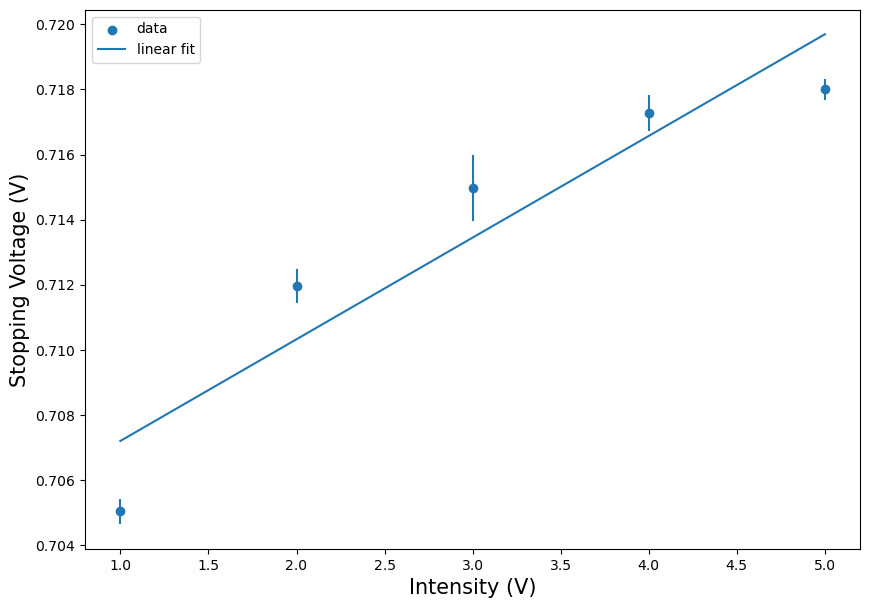

In [83]:
# SV VS INTENSITY

fig, ax = plt.subplots()

# make the data
x = np.array(intensity) # intensity
y = np.array(y_SV) # Stopping Voltage
    
# errorbars
y_err = np.array(y_SV_unc)

# plot
ax.scatter(x, y, label="data")
ax.set_ylabel("Stopping Voltage (V)", fontsize=15)
ax.set_xlabel("Intensity (V)", fontsize=15)
ax.errorbar(x, y, yerr=y_err, fmt='none')

# fit the line
p = np.polyfit(x, y, 1)
m = p[0]
b = p[1]
ax.plot(x, m*x+b, label="linear fit")
#ax.plot(x, 6.63E-34/1.602176634E-19*x+b-0.5, label="correct")

# parameter uncertainties
N = len(intensity)
delta = N*np.sum(x**2) - np.sum(x)**2
print(N, delta)
covar = np.sum((y-(b+m*x))**2)/(N-2)
m_unc = np.sqrt(N*covar/delta)
b_unc = np.sqrt(covar*np.sum(x**2)/delta)

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./SVint.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

print("m:", m, "±", m_unc)
print("b:", b, "±", b_unc)

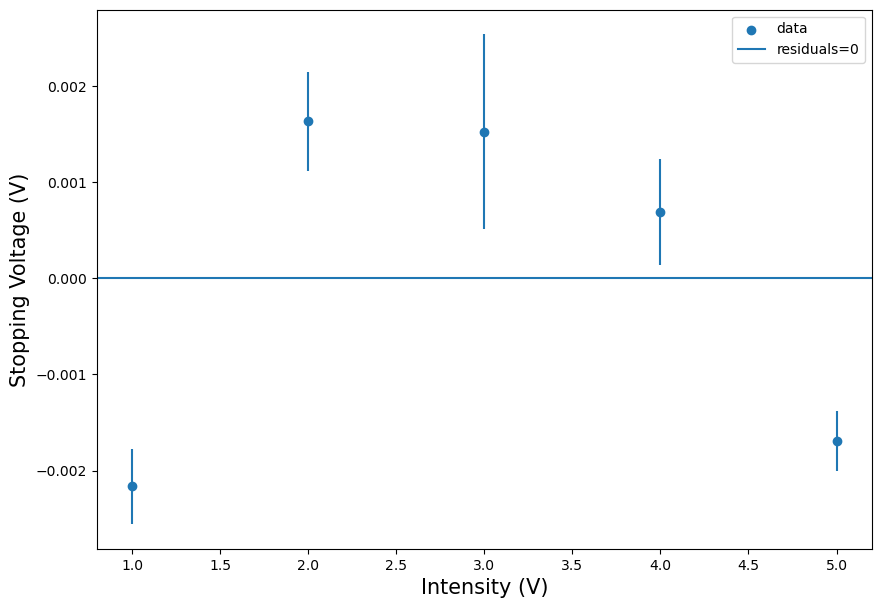

In [84]:
# residuals
fig, ax = plt.subplots()

# make the data
x = np.array(intensity) # intensity
y = np.array(y_SV) # Stopping Voltage
    
# errorbars
y_err = np.array(y_SV_unc)

# line of best fit
# - outliers already corrected for 0 and 8
fit = m*x+b

res = y-fit
    
# plot
ax.scatter(x, res, label="data")
ax.set_ylabel("Stopping Voltage (V)", fontsize=15)
ax.set_xlabel("Intensity (V)", fontsize=15)
ax.errorbar(x, res, yerr=y_err, fmt='none')
ax.axhline(y=0, label="residuals=0")

# save
ax.legend()
fig.set_size_inches(10, 7)
name = "./SVint_res.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [85]:
# r
r = np.corrcoef(x, y)
print("r:", r)

r: [[1.         0.93917501]
 [0.93917501 1.        ]]


In [86]:
# reduced chi-squared
y_avg = np.mean(y) 
chisq = 0
print(y)
print(y_avg)
print(fit)
print()

for i in range(0, len(intensity)):
    num = (y[i]-fit[i])**2
    denom = (y[i]-y_avg)**2
    chisq += num/denom
print(chisq)
chisq = np.sum((y-fit)**2/(y-y_avg)**2)
print(chisq)
print(N)
redchisq = chisq/(N-2)
print(redchisq)

[0.70503233 0.71196    0.71497767 0.71726667 0.71800433]
0.7134482
[0.70719807 0.71032313 0.7134482  0.71657327 0.71969833]

2.447212304392353
2.447212304392353
5
0.815737434797451


## testing

### try fitting considering error bars

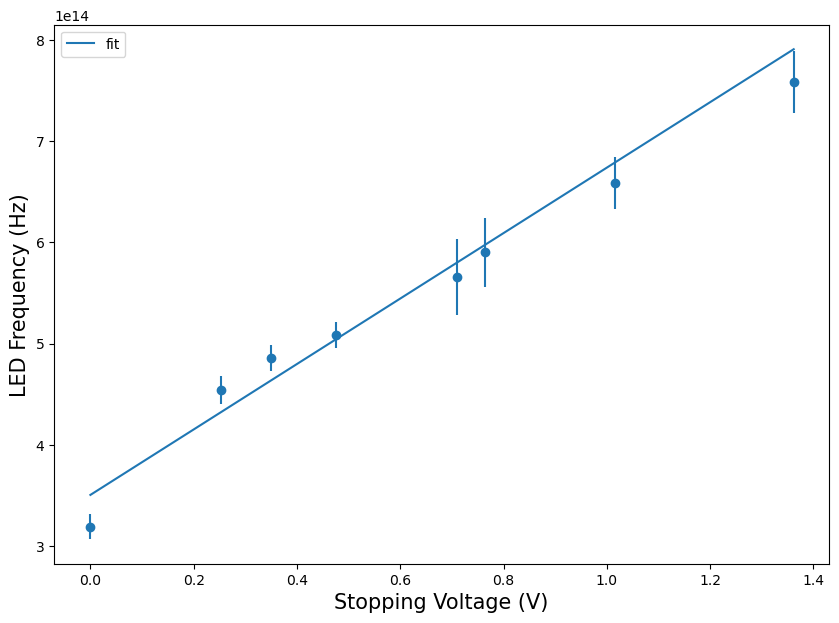

In [35]:
from scipy.optimize import curve_fit
# try fitting considering error bars
# flip x and y since linear and I want to consider error bars to
#make the fit more accurate, but scipy.optimize.curve_fit only 
#considers y-errors if I use sigma

# make the data
x = np.array(Vstop) # Stopping Voltage
y = np.array(freq) # frequency
    
# errorbars
x_err = np.array(Vstop_unc)
y_err = np.array(freq_unc)
    
# plot
fig, ax = plt.subplots()
    
ax.scatter(x, y)
ax.set_ylabel("LED Frequency (Hz)", fontsize=15)
ax.set_xlabel("Stopping Voltage (V)", fontsize=15)
ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none')

# fit the line
def linear(x, a, b):
    return a*x + b
popt, pcov = curve_fit(linear, x, y, p0 = [3.08E14, 3.52E14], sigma=y_err, absolute_sigma=True)
m = popt[0]
b = popt[1]
ax.plot(x, m*x+b, label="fit")
#ax.plot(x, 6.63E-34/1.602176634E-19*x+b-0.5, label="correct")
ax.legend()
    
fig.set_size_inches(10, 7)

# save
name = "./Vstopf_uncfit.png"
fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [36]:
print(m)
print(b)

323852090848064.1
350230638435318.56


In [38]:
b *= -m
m = 1/m
print(m)
print(b)

f0 = np.array(m) * 1.602176634E-19 # * e
print(f0)

323852090848064.1
350230638435318.56
5.188682528288136e-05


### try approximating stopping voltage using photocurrent

In [22]:
# try out approximating stopping voltage using photocurrent
# hopefully it's about linear since photocurrent is pretty small
# + I don't have any other data points
# + we recorded ranges, not set values, but I'll make some assumptions so
#   we can get another voltage point out of this

# PC is 0 at infrared, so skipping that data point
# ONLY 7 DATA POINTS
# SV low to high
SV = [[0.0129E-3, 0.013E-3, 0.0131E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3, 0.0139E-3, 0.014, 0.0141E-3], \
      [0.0129E-3, 0.013E-3, 0.0131E-3]]
SV_unc = 0.0001E-3

# PC high to low, Amps
# measured voltage (in mV) divided by 100kohms
PC = [[0.632E-8, 0.628E-8, 0.624E-8], \
      [2.101E-8, 2.092E-8, 2.083E-8], \
      [2.925E-8, 2.875E-8, 2.825E-8], \
      [21.278E-8, 21.2575E-8, 21.237E-8], \
      [32.489E-8, 32.4635E-8, 32.438E-8], \
      [52.86E-8, 52.78E-8, 52.70E-8, 48.24E-8, 48.17E-8, 48.1E-8], \
      [54.63E-8, 54.555E-8, 54.48E-8]]
# UNCS STILL IN mV RN
PC_unc = [[0.004, 0.004, 0.004], \
          [0.009, 0.009, 0.009], \
          [0.05, 0.05, 0.05], \
          [0.0205, 0.0205, 0.0205], \
          [0.0255, 0.0255, 0.0255], \
          [0.08, 0.08, 0.08, 0.07, 0.07, 0.07], \
          [0.075, 0.075, 0.075]]
# unc conversion
for i in range(0, len(PC_unc)):
    for j in range(0, len(PC_unc[i])):
        PC_unc[i][j] *= 10**(-3) # mV to V
        PC_unc[i][j] = PC[i][j] * PC_unc[i][j] / (PC[i][j] * 10**5)
        
print(PC)
print(PC_unc)

[[6.32e-09, 6.28e-09, 6.24e-09], [2.101e-08, 2.092e-08, 2.083e-08], [2.925e-08, 2.875e-08, 2.825e-08], [2.1278e-07, 2.12575e-07, 2.1237e-07], [3.2489e-07, 3.24635e-07, 3.2438e-07], [5.286e-07, 5.278e-07, 5.27e-07, 4.824e-07, 4.817e-07, 4.81e-07], [5.463e-07, 5.4555e-07, 5.448e-07]]
[[4e-11, 4e-11, 4e-11], [9e-11, 9e-11, 9e-11], [5e-10, 5e-10, 5e-10], [2.05e-10, 2.0499999999999996e-10, 2.05e-10], [2.5500000000000005e-10, 2.55e-10, 2.5499999999999995e-10], [8e-10, 8.000000000000001e-10, 8.000000000000001e-10, 7.000000000000001e-10, 7.000000000000002e-10, 7.000000000000001e-10], [7.499999999999999e-10, 7.5e-10, 7.5e-10]]


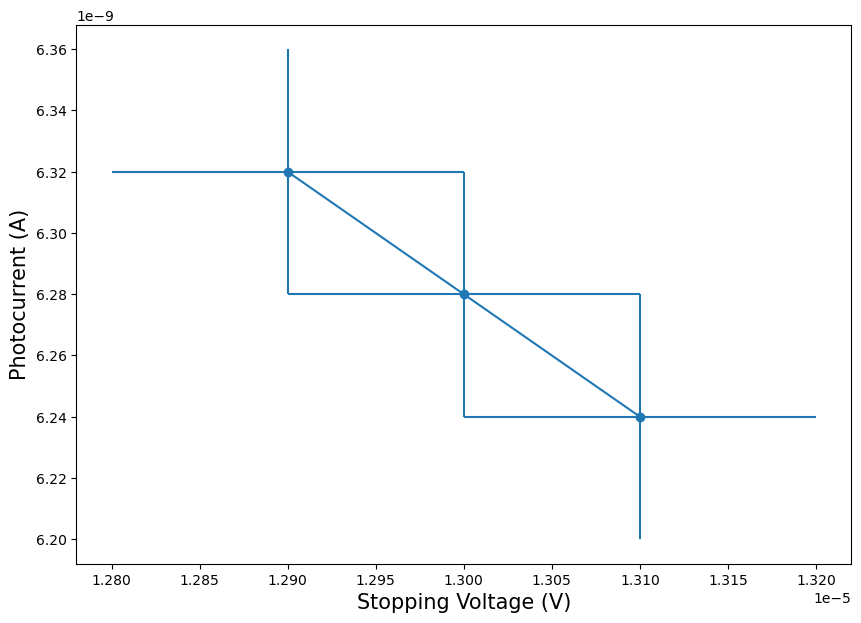

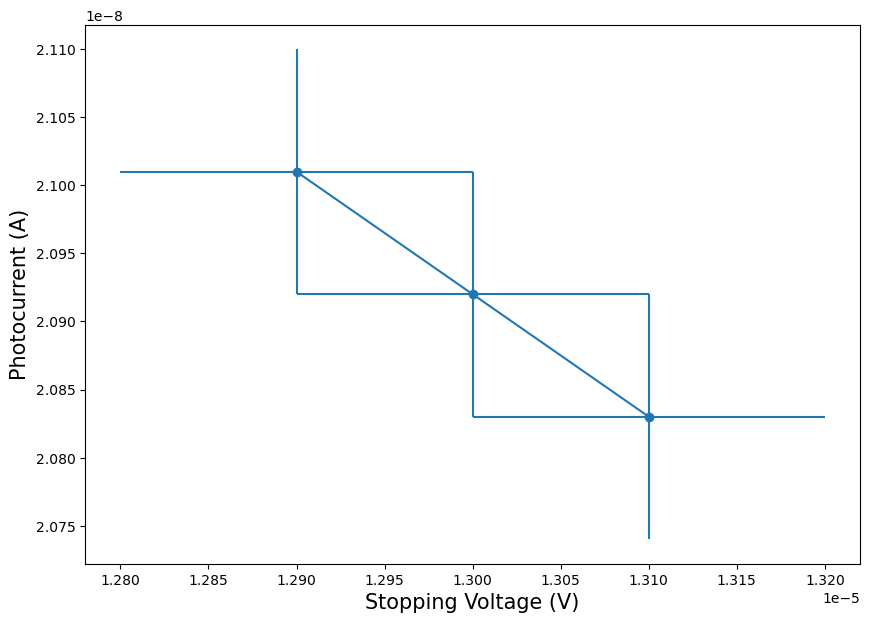

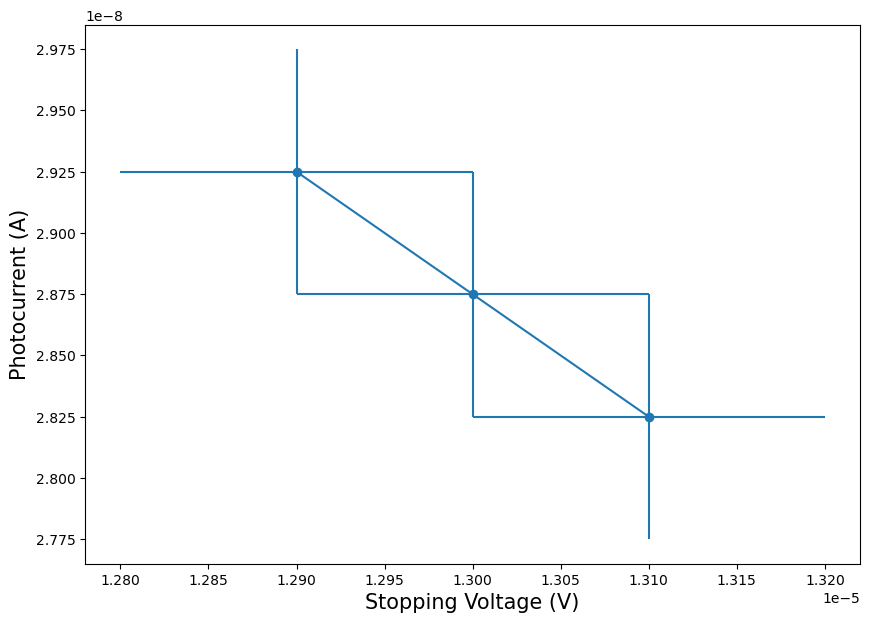

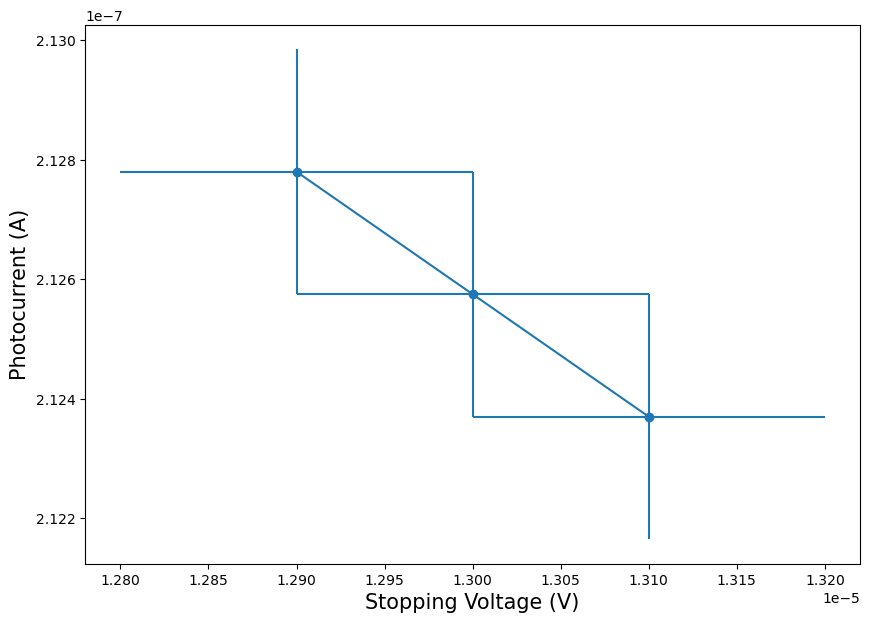

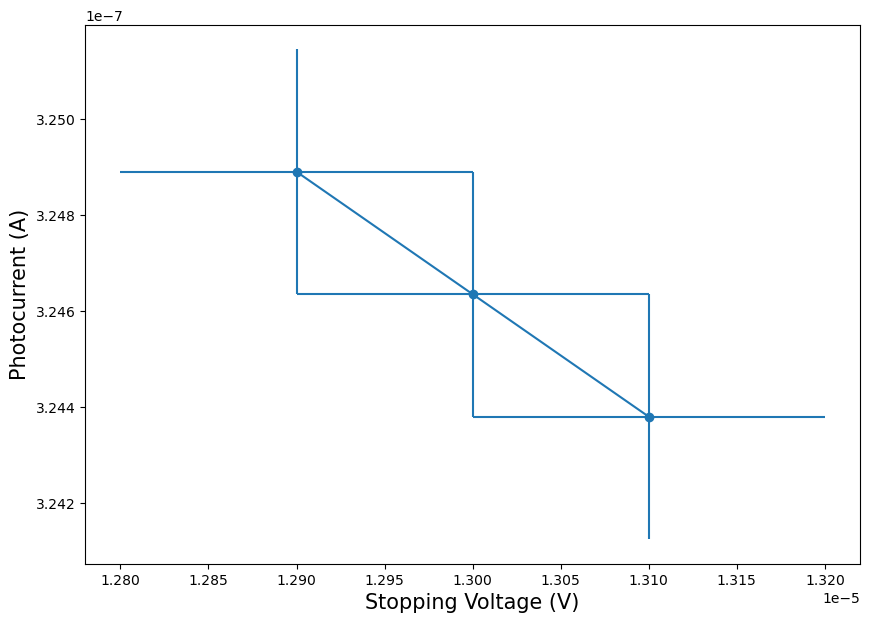

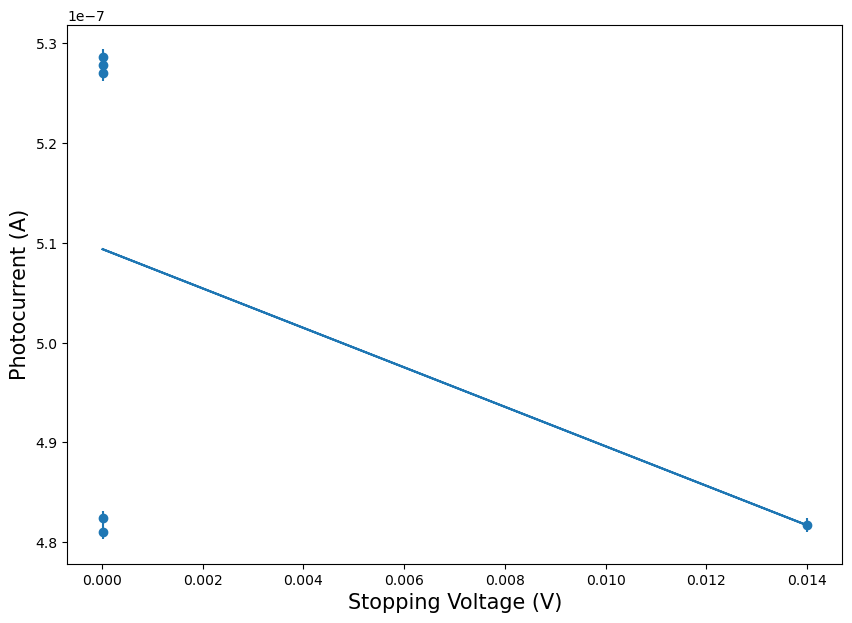

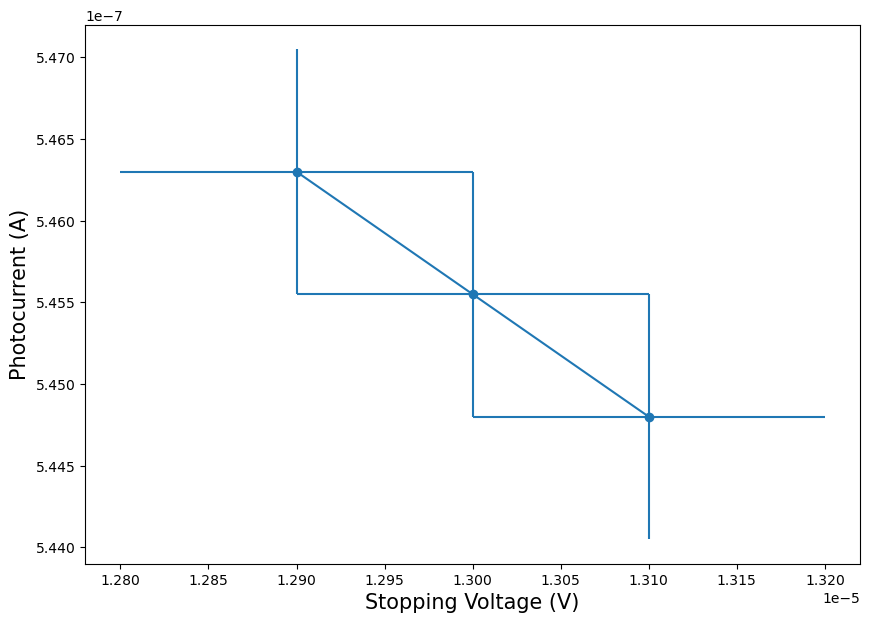

In [23]:
p1 = [0] * 7
p2 = [0] * 7

# plot pc vs sv
for i in range(0, len(PC)):
    # make the data
    x = np.array(SV[i]) # frequency
    y = np.array(PC[i]) # stopping voltage
    
    # errorbars
    x_err = np.array(SV_unc)
    y_err = np.array(PC_unc[i])
    
    # plot
    fig, ax = plt.subplots()
    
    ax.scatter(x, y)
    ax.set_ylabel("Photocurrent (A)", fontsize=15)
    ax.set_xlabel("Stopping Voltage (V)", fontsize=15)
    ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none')

    # fit the line
    p = np.polyfit(x, y, 1)
    p1[i] = p[0]
    p2[i] = p[1]
    ax.plot(x, p1[i]*x+p2[i])
    
    fig.set_size_inches(10, 7)

    # save
    name = "./Vstop_other/SVPC_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [31]:
print(p1)
print(p2)
# I don't think these are valid, not using this data

[-0.0004000000000000167, -0.000900000000000071, -0.005000000000000219, -0.002050000000000444, -0.0025500000000003836, -1.977948306638103e-06, -0.007500000000001432]
[1.148000000000022e-08, 3.2620000000000923e-08, 9.375000000000289e-08, 2.3922500000000574e-07, 3.5778500000000487e-07, 5.093872998049128e-07, 6.430500000000186e-07]
